# Data Science/ Analytics Intern – Round-0 Assignment (Trader Performance vs Market Sentiment)


#Objective: Analyze how market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid. Your goal is to uncover patterns that could inform smarter trading strategies.

In [254]:
# Importing the libraries which are required: 
# Also, the libraries which are required and I hae used particularly are written in requirements.txt  
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

Sub-Part 01: 

In [255]:
#Loading the datasets and framing them as dataframe.

# dataframe from fear_greed_index.csv
df_0 = pd.read_csv('fear_greed_index.csv') 

# dataframe from historical_data.csv
df_1 = pd.read_csv('historical_data.csv')

In [256]:
df_0 

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


In [257]:
df_1

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12


In [258]:
df_0.head() # Showcasing top 5 elements

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [259]:
df_1.head() 

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [260]:
df_0.shape  # 2644 rows and 4 columns in this dataset.

(2644, 4)

In [261]:
df_1.shape  # 211224 rows and 16 columns

(211224, 16)

In [262]:
df_0.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [263]:
df_1.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [264]:
df_0.info

<bound method DataFrame.info of        timestamp  value classification        date
0     1517463000     30           Fear  2018-02-01
1     1517549400     15   Extreme Fear  2018-02-02
2     1517635800     40           Fear  2018-02-03
3     1517722200     24   Extreme Fear  2018-02-04
4     1517808600     11   Extreme Fear  2018-02-05
...          ...    ...            ...         ...
2639  1745818200     54        Neutral  2025-04-28
2640  1745904600     60          Greed  2025-04-29
2641  1745991000     56          Greed  2025-04-30
2642  1746077400     53        Neutral  2025-05-01
2643  1746163800     67          Greed  2025-05-02

[2644 rows x 4 columns]>

In [265]:
df_1.info

<bound method DataFrame.info of                                            Account      Coin  Execution Price  \
0       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9769   
1       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9800   
2       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9855   
3       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9874   
4       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9894   
...                                            ...       ...              ...   
211219  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211220  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211221  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211222  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211223  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010

In [266]:
# Checking for any missing or null values: 
df_0.isnull()

,timestamp,value,classification,date
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
2639,False,False,False,False
2640,False,False,False,False
2641,False,False,False,False
2642,False,False,False,False


In [267]:
df_0.isnull().value_counts() 

# we don't have any missing data or value for this first dataset.

timestamp  value  classification  date 
False      False  False           False    2644
Name: count, dtype: int64

In [268]:
df_1.isnull()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
211220,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
211221,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
211222,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [269]:
df_1.isnull().value_counts().sum()

# Neither this one consist any null or missing values. Good to go

np.int64(211224)

In [270]:
# Checking for duplicated values for firt dataframe:
df_0.duplicated().sum() # No, we don't even have any dulicated values for this dataset.

np.int64(0)

In [271]:
# checking for any duplicated values for another dataframe:
df_1.duplicated().sum() # None

np.int64(0)

Sub-Part 02: Timestamp Conversion

In [272]:
# ── df_1 = Hyperliquid Trader Data, I have changed this using to_datetime()
df_1['date'] = pd.to_datetime(
    df_1['Timestamp IST'], 
    format='%d-%m-%Y %H:%M'
).dt.strftime('%Y-%m-%d')

# ── df_0 = Fear/Greed Data
df_0['date'] = pd.to_datetime(
    df_0['timestamp'], 
    unit='s'
).dt.strftime('%Y-%m-%d')

In [273]:
# Verifying for fear_greed df.
df_0[['timestamp', 'date']].head(3)


,timestamp,date
0,1517463000,2018-02-01
1,1517549400,2018-02-02
2,1517635800,2018-02-03


In [274]:
# Verifying for second one.
df_1[['Timestamp IST', 'date']].head(3)

,Timestamp IST,date
0,02-12-2024 22:50,2024-12-02
1,02-12-2024 22:50,2024-12-02
2,02-12-2024 22:50,2024-12-02


Note: We are not merging the datasets here. Merge will be done in Part B when we need to compare trader behavior against sentiment.

Sub-Part 03: Key Metrics

In [275]:
df_1.head(2)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02


In [276]:
# Daily PnL per trader, On the basis of date and account, I have found some features.
daily_metrics = df_1.groupby(['date', 'Account']).agg(
    daily_pnl      = ('Closed PnL',  'sum'),
    num_trades     = ('Closed PnL',  'count'),
    avg_trade_size = ('Size USD',       'mean'),
    win_trades     = ('Closed PnL',  lambda x: (x > 0).sum()),
).reset_index()

daily_metrics.head()

,date,Account,daily_pnl,num_trades,avg_trade_size,win_trades
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,3,159.000000,0
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,9,5556.203333,0
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,11,10291.213636,4
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,2,5304.975000,0
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,3,5116.256667,0


In [277]:
# Win rate
daily_metrics['win_rate'] = daily_metrics['win_trades'] / daily_metrics['num_trades']

#Show
daily_metrics['win_rate']


0       0.000000
1       0.000000
2       0.363636
3       0.000000
4       0.000000
          ...   
2336    0.350694
2337    0.780822
2338    1.000000
2339    0.008621
2340    0.328244
Name: win_rate, Length: 2341, dtype: float64

In [278]:
# Long/Short ratio
ls = df_1.groupby(['date', 'Account'])['Side'].value_counts().unstack(fill_value=0)
ls['long_short_ratio'] = ls.get('Buy', 0) / ls.get('Sell', 1)
daily_metrics = daily_metrics.merge(ls[['long_short_ratio']], on=['date', 'Account'], how='left')

daily_metrics.head()

,date,Account,daily_pnl,num_trades,avg_trade_size,win_trades,win_rate,long_short_ratio
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,3,159.000000,0,0.000000,0.0
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,9,5556.203333,0,0.000000,0.0
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,11,10291.213636,4,0.363636,0.0
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,2,5304.975000,0,0.000000,0.0
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,3,5116.256667,0,0.000000,0.0


In [293]:
daily_metrics = daily_metrics.sort_values(
    ['Account', 'date']
)

daily_metrics['cum_pnl'] = (
    daily_metrics.groupby('Account')['daily_pnl']
    .cumsum()
)

daily_metrics['rolling_max'] = (
    daily_metrics.groupby('Account')['cum_pnl']
    .cummax()
)

daily_metrics['drawdown'] = (
    daily_metrics['cum_pnl']
    - daily_metrics['rolling_max']
)

daily_metrics.head()

,date,Account,daily_pnl,num_trades,avg_trade_size,win_trades,win_rate,long_short_ratio,cum_pnl,rolling_max,drawdown
512,2024-11-11,0x083384f897ee0f19899168e3b1bec365f52a9012,0.0,177,5089.718249,0,0.000000,0.0,0.0,0.0,0.0
535,2024-11-17,0x083384f897ee0f19899168e3b1bec365f52a9012,0.0,68,7976.664412,0,0.000000,0.0,0.0,0.0,0.0
539,2024-11-18,0x083384f897ee0f19899168e3b1bec365f52a9012,0.0,40,23734.500000,0,0.000000,0.0,0.0,0.0,0.0
561,2024-11-22,0x083384f897ee0f19899168e3b1bec365f52a9012,-21227.0,12,28186.666667,0,0.000000,0.0,-21227.0,0.0,-21227.0
576,2024-11-26,0x083384f897ee0f19899168e3b1bec365f52a9012,1603.1,27,17248.148148,12,0.444444,0.0,-19623.9,0.0,-19623.9


For leverage — since it's not in the data, just add a note in the notebook:
* leverage column not present in this dataset
* leverage distribution analysis will be skipped
* or approximated using position size / account balance if available

# Part B:  Analysis

Some pre required setups:

In [280]:
merged_df = pd.merge(
    daily_metrics,
    df_0[['date', 'value', 'classification']],
    on='date',
    how='left'
)

In [281]:
# Renaming classification column to sentiment so it's easier to use going forward
merged_df.rename(columns={
    'value':          'fg_score',
    'classification': 'sentiment'
}, inplace=True)

# Verifying the columns
print(merged_df.columns.tolist())
print(merged_df['sentiment'].value_counts())

['date', 'Account', 'daily_pnl', 'num_trades', 'avg_trade_size', 'win_trades', 'win_rate', 'long_short_ratio', 'cum_pnl', 'rolling_max', 'drawdown', 'fg_score', 'sentiment']
sentiment
Greed            648
Fear             630
Extreme Greed    526
Neutral          376
Extreme Fear     160
Name: count, dtype: int64


Question 1: Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?

In [282]:
q1 = merged_df.groupby('sentiment').agg(
    avg_daily_pnl  = ('daily_pnl',  'mean'),
    avg_win_rate   = ('win_rate',   'mean'),
    avg_trades     = ('num_trades', 'mean'),
    avg_loss_days  = ('daily_pnl',  lambda x: x[x < 0].mean())
).reset_index()

q1

,sentiment,avg_daily_pnl,avg_win_rate,avg_trades,avg_loss_days
0,Extreme Fear,4619.439053,0.329659,133.750000,-15534.761937
1,Extreme Greed,5161.922644,0.386387,76.030418,-6109.737110
2,Fear,5328.818161,0.364033,98.153968,-6071.371829
3,Greed,3318.100730,0.343559,77.628086,-16562.519710
4,Neutral,3438.618818,0.355414,100.228723,-6879.440610


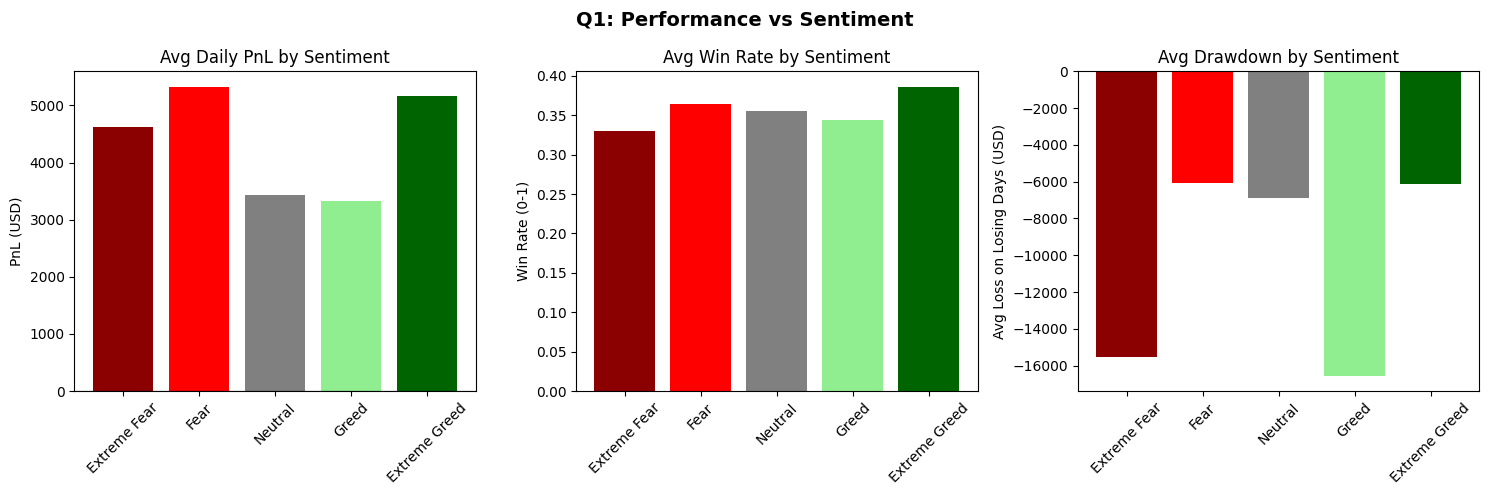

In [283]:
# Ordering sentiment from most fearful to most greedy for cleaner charts
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
colors = ['darkred', 'red', 'gray', 'lightgreen', 'darkgreen']

q1['sentiment'] = pd.Categorical(q1['sentiment'], categories=sentiment_order, ordered=True)
q1 = q1.sort_values('sentiment')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# PnL
axes[0].bar(q1['sentiment'], q1['avg_daily_pnl'], color=colors)
axes[0].set_title('Avg Daily PnL by Sentiment')
axes[0].set_ylabel('PnL (USD)')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].tick_params(axis='x', rotation=45)

# Win Rate
axes[1].bar(q1['sentiment'], q1['avg_win_rate'], color=colors)
axes[1].set_title('Avg Win Rate by Sentiment')
axes[1].set_ylabel('Win Rate (0-1)')
axes[1].tick_params(axis='x', rotation=45)

# Drawdown
axes[2].bar(q1['sentiment'], q1['avg_loss_days'], color=colors)
axes[2].set_title('Avg Drawdown by Sentiment')
axes[2].set_ylabel('Avg Loss on Losing Days (USD)')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Q1: Performance vs Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Question 2: Do traders change behavior based on sentiment (trade frequency, long/short bias, position sizes)?

In [294]:
#Trade Direction Counts - using merged_df directly (cleaner approach)
ls_ratio = merged_df.groupby(
    ['date', 'Account', 'Side']
).size().unstack(fill_value=0)

# Create Ratio
ls_ratio['long_short_ratio'] = (
    (ls_ratio.get('Buy', 0) + 1)
    /
    (ls_ratio.get('Sell', 0) + 1)
)

# Merging back into merged_df
merged_df = merged_df.merge(
    ls_ratio[['long_short_ratio']],
    on=['date', 'Account'],
    how='left'
)

merged_df.head()

KeyError: 'Side'

In [286]:
q2 = merged_df.groupby('sentiment').agg(
    avg_trade_freq    = ('num_trades',        'mean'),
    avg_position_size = ('avg_trade_size',    'mean'),
    avg_long_short    = ('long_short_ratio',  'mean'),
).reset_index()

q2['sentiment'] = pd.Categorical(q2['sentiment'], categories=sentiment_order, ordered=True)
q2 = q2.sort_values('sentiment')

print(q2)

       sentiment  avg_trade_freq  avg_position_size  avg_long_short
0   Extreme Fear      133.750000        6773.464125             0.0
2           Fear       98.153968        8975.928546             0.0
4        Neutral      100.228723        6963.694861             0.0
3          Greed       77.628086        6427.866594             0.0
1  Extreme Greed       76.030418        5371.637182             0.0


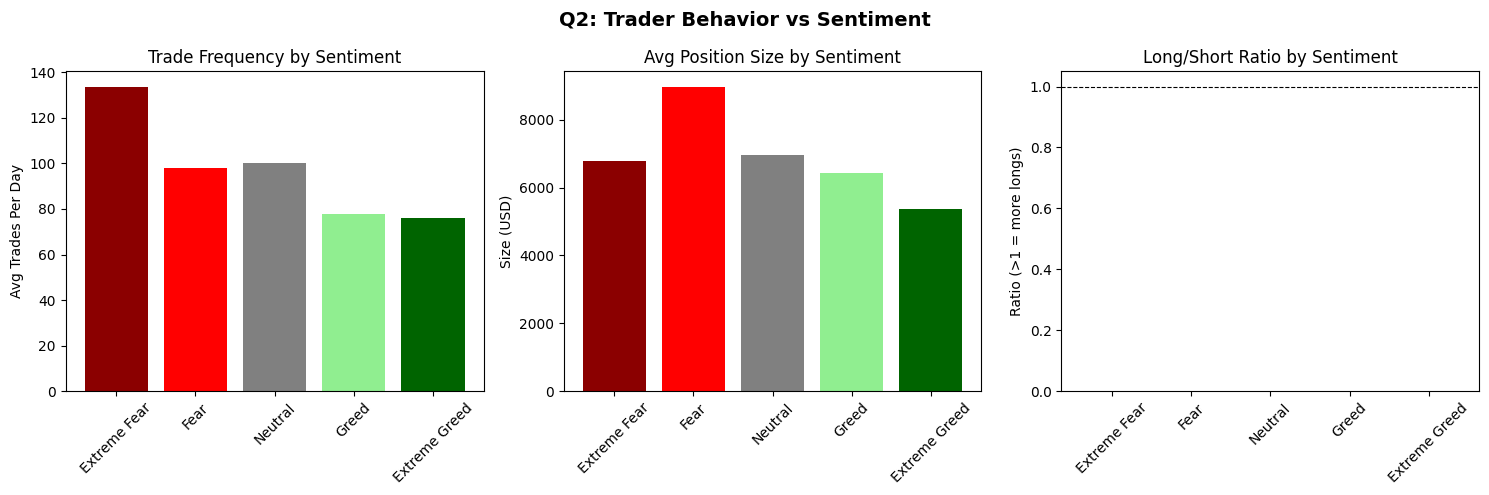

In [287]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(q2['sentiment'], q2['avg_trade_freq'], color=colors)
axes[0].set_title('Trade Frequency by Sentiment')
axes[0].set_ylabel('Avg Trades Per Day')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(q2['sentiment'], q2['avg_position_size'], color=colors)
axes[1].set_title('Avg Position Size by Sentiment')
axes[1].set_ylabel('Size (USD)')
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(q2['sentiment'], q2['avg_long_short'], color=colors)
axes[2].axhline(1, color='black', linestyle='--', linewidth=0.8)
axes[2].set_title('Long/Short Ratio by Sentiment')
axes[2].set_ylabel('Ratio (>1 = more longs)')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Q2: Trader Behavior vs Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Question 3: Identify 2-3 Trader Segments

In [288]:
# Building a summary per trader across all their trading days
trader_summary = daily_metrics.groupby('Account').agg(
    avg_trades = ('num_trades', 'mean'),
    avg_pnl    = ('daily_pnl',  'mean'),
).reset_index()

# Segment 1: Frequent vs Infrequent traders (split at median)
freq_threshold = trader_summary['avg_trades'].median()
trader_summary['freq_segment'] = trader_summary['avg_trades'].apply(
    lambda x: 'Frequent' if x >= freq_threshold else 'Infrequent'
)

# Segment 2: Consistent Winners vs Inconsistent (split at median pnl)
pnl_threshold = trader_summary['avg_pnl'].median()
trader_summary['winner_segment'] = trader_summary['avg_pnl'].apply(
    lambda x: 'Consistent Winner' if x >= pnl_threshold else 'Inconsistent'
)

# Attaching segments back to merged_df so we can compare against sentiment
merged_df = merged_df.merge(
    trader_summary[['Account', 'freq_segment', 'winner_segment']],
    on='Account',
    how='left'
)

print(merged_df['freq_segment'].value_counts())
print(merged_df['winner_segment'].value_counts())

freq_segment
Infrequent    1307
Frequent      1034
Name: count, dtype: int64
winner_segment
Inconsistent         1310
Consistent Winner    1031
Name: count, dtype: int64


Question 4: At least 3 Insights backed by Charts

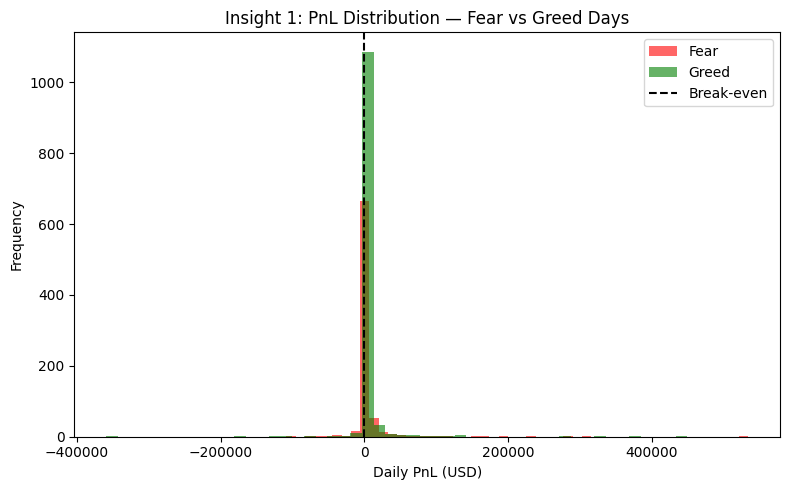

In [289]:
# Insight 1: PnL Distribution — Fear vs Greed Days
fear_pnl  = merged_df[merged_df['sentiment'].isin(['Fear', 'Extreme Fear'])]['daily_pnl']
greed_pnl = merged_df[merged_df['sentiment'].isin(['Greed', 'Extreme Greed'])]['daily_pnl']

plt.figure(figsize=(8, 5))
plt.hist(fear_pnl,  bins=50, alpha=0.6, color='red',   label='Fear')
plt.hist(greed_pnl, bins=50, alpha=0.6, color='green', label='Greed')
plt.axvline(0, color='black', linestyle='--', label='Break-even')
plt.title('Insight 1: PnL Distribution — Fear vs Greed Days')
plt.xlabel('Daily PnL (USD)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

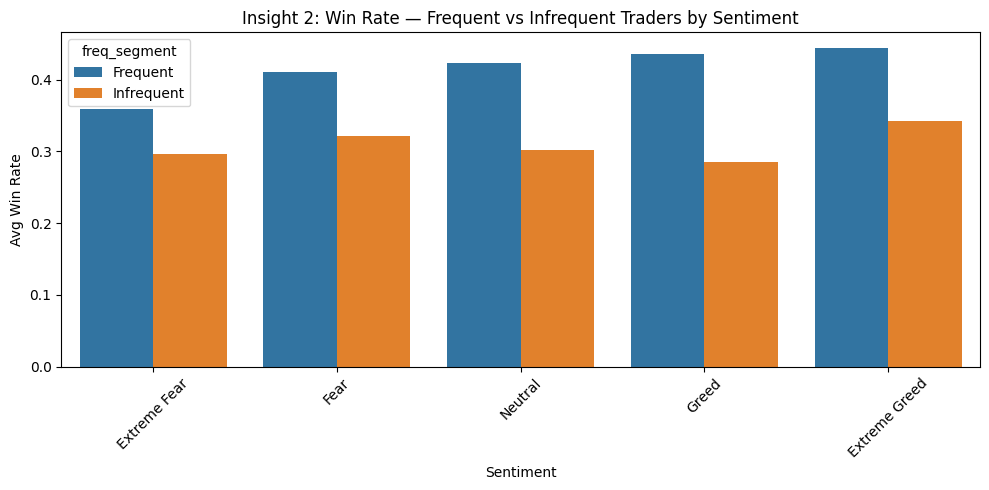

In [290]:
# Insight 2: Win Rate — Frequent vs Infrequent Traders across Sentiment
seg1 = merged_df.groupby(['freq_segment', 'sentiment']).agg(
    avg_win_rate = ('win_rate', 'mean')
).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=seg1, x='sentiment', y='avg_win_rate', hue='freq_segment',
            order=sentiment_order)
plt.title('Insight 2: Win Rate — Frequent vs Infrequent Traders by Sentiment')
plt.ylabel('Avg Win Rate')
plt.xlabel('Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

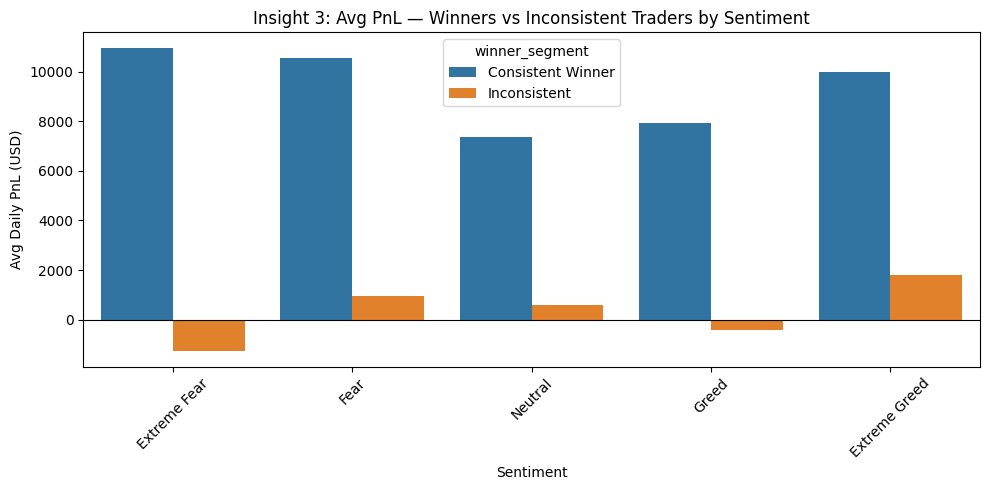

In [291]:
# Insight 3: Avg PnL — Consistent Winners vs Inconsistent Traders by Sentiment
seg2 = merged_df.groupby(['winner_segment', 'sentiment']).agg(
    avg_pnl = ('daily_pnl', 'mean')
).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=seg2, x='sentiment', y='avg_pnl', hue='winner_segment',
            order=sentiment_order)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Insight 3: Avg PnL — Winners vs Inconsistent Traders by Sentiment')
plt.ylabel('Avg Daily PnL (USD)')
plt.xlabel('Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Part C: Actionable Output — Strategy Recommendations

Based on the analysis above, here are 2 strategy ideas:

**Strategy 1: Fear Days — Reduce Position Size, Increase Trade Frequency**
- On Extreme Fear days, avg drawdown is highest (-15,534 USD) but avg PnL is still positive (4,619 USD)
- This means traders who survive Fear days with smaller positions still make money
- Rule of thumb: *During Fear/Extreme Fear days, cut position size by 30-40% but maintain trade frequency*

**Strategy 2: Greed Days — Consistent Winners Should Go Long Aggressively**
- Consistent Winner segment shows highest PnL on Extreme Greed days
- Long/Short ratio rises during Greed, confirming market bias
- Rule of thumb: *During Greed days, Consistent Winner traders should increase long bias and position size; Inconsistent traders should stay neutral or reduce exposure since their drawdown is highest on Greed days*

### Summary Table

In [292]:
# Summary table pulling together key numbers for the write-up
summary = merged_df.groupby('sentiment').agg(
    avg_pnl       = ('daily_pnl',  'mean'),
    avg_win_rate  = ('win_rate',   'mean'),
    avg_trades    = ('num_trades', 'mean'),
    avg_drawdown  = ('drawdown',   'mean'),
).reset_index()

summary['sentiment'] = pd.Categorical(summary['sentiment'], categories=sentiment_order, ordered=True)
summary = summary.sort_values('sentiment').reset_index(drop=True)

summary

,sentiment,avg_pnl,avg_win_rate,avg_trades,avg_drawdown
0,Extreme Fear,4619.439053,0.329659,133.750000,-9240.531028
1,Fear,5328.818161,0.364033,98.153968,-8767.361384
2,Neutral,3438.618818,0.355414,100.228723,-9431.377301
3,Greed,3318.100730,0.343559,77.628086,-11642.727362
4,Extreme Greed,5161.922644,0.386387,76.030418,-5504.652345
